# Taller B3-T4: Redes Neuronales para Forecasting
## Ventana entrada: 10 dias
## Ventana salida: 30 dias

- **Parte 1: Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2: Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [38]:
VENTANA_ENTRADA = 10   # dias de entrada
VENTANA_SALIDA  = 30   # dias de salida

In [39]:
import sys
sys.path.insert(0, '..')
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from utilidades.carga_datos import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
import utilidades.modelos as modelos_mod
importlib.reload(modelos_mod)
from utilidades.modelos import (
    construir_dense,
    construir_dense_v2,
    construir_dense_v3,
    construir_dense_v4,
    construir_dense_v5,
    construir_dense_v6,
    construir_recurrente,
    construir_conv1d,
    construir_mixto,
    plot_best_history,
    crear_callbacks_base,
    CALLBACKS,
    entrenar_candidatos_parametricos,
    seleccionar_mejor_familia,
)
from utilidades.evaluacion import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos import graficar_convergencia, graficar_barras_mae


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [40]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16151, 10, 23)  |  y: (16151, 23)
Train: (13808, 10, 23)  Val: (727, 10, 23)  Test: (1616, 10, 23)


## 1.2 Baseline Lineal


In [41]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))

            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.002152  0.001795  0.002355         0
BuyAndHold   0.002173  0.001784  0.002319         0


## 1.3 Modelos Dense (seis opciones)


Entrenando Dense (1/6)...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 14.
{'modelo': 'Dense', 'mae_train': 0.0021728852001813444, 'mae_val': 0.001783511051154774, 'mae_test': 0.002317175482913954, 'n_params': 94999}
Entrenando Dense_v2 (2/6)...

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 33: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 15.
{'modelo': 'Dense_v2', 'mae_train': 0.0

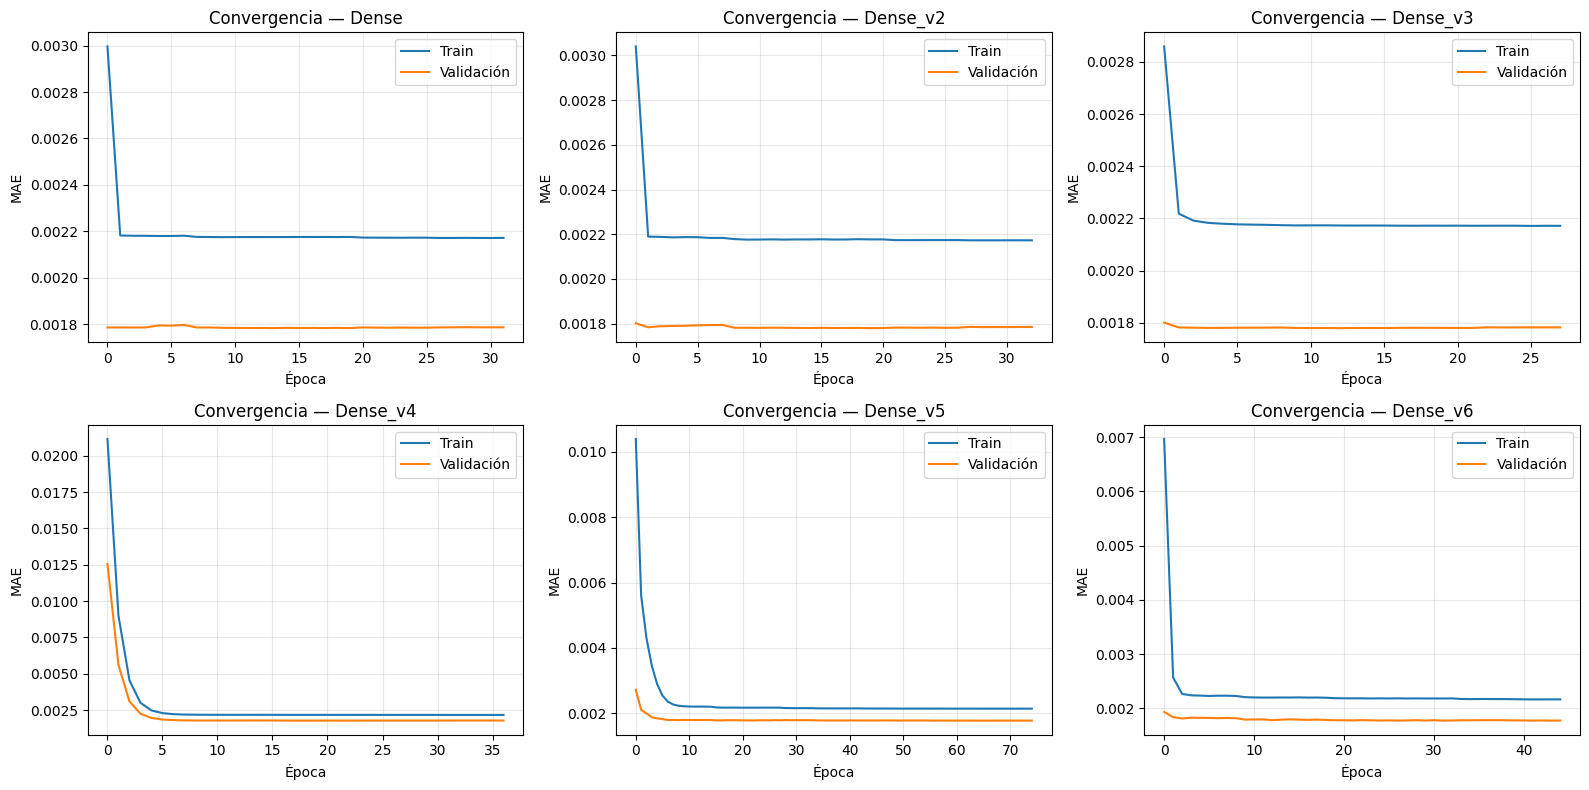

,modelo,mae_train,mae_val,mae_test,n_params
0,Dense_v6,0.002175,0.001775,0.002331,20791
1,Dense_v5,0.002140,0.001778,0.002346,65047
2,Dense_v4,0.002175,0.001778,0.002322,39319
3,Dense_v3,0.002171,0.001780,0.002319,292247
4,Dense_v2,0.002175,0.001781,0.002320,40663
5,Dense,0.002173,0.001784,0.002317,94999


In [42]:
dense_constructores = {
    'Dense': lambda: construir_dense(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v2': lambda: construir_dense_v2(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v3': lambda: construir_dense_v3(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v4': lambda: construir_dense_v4(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v5': lambda: construir_dense_v5(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v6': lambda: construir_dense_v6(X_train_plano.shape[1], y_train.shape[1]),
}

historias_dense_opciones = {}
modelos_dense_opciones = {}
resultados_dense_opciones = []

for i, (nombre, constructor) in enumerate(dense_constructores.items(), start=1):
    print(f'Entrenando {nombre} ({i}/{len(dense_constructores)})...')
    keras.backend.clear_session()
    keras.utils.set_random_seed(42 + i)
    modelo = constructor()
    hist = modelo.fit(
        X_train_plano, y_train,
        validation_data=(X_val_plano, y_val),
        epochs=120,
        batch_size=256,
        callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
        verbose=0,
    )
    resultado = evaluar_modelo(
        modelo, X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=nombre,
    )
    historias_dense_opciones[nombre] = hist
    modelos_dense_opciones[nombre] = modelo
    resultados_dense_opciones.append(resultado)
    print(resultado)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nombre in zip(axes.ravel(), dense_constructores.keys()):
    graficar_convergencia(historias_dense_opciones[nombre], nombre, ax=ax)
plt.tight_layout()
plt.show()

df_dense_opciones = pd.DataFrame(resultados_dense_opciones).sort_values(
    ['mae_val', 'mae_test']
).reset_index(drop=True)
display(df_dense_opciones.round(6))


## 1.3.1 Mejor Dense parametrizado


Entrenando Dense_param_128_64_32 (1/3)...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'mae_train': 0.0021725550674957573, 'mae_val': 0.0017849214122061165, 'mae_test': 0.0023183607206191414, 'best_train_val_gap': 0.0001200925325974822, 'best_epoch': 97}
Entrenando Dense_param_96_48 (2/3)...
{'mae_train': 0.002171747439885338, 'mae_val': 0.0017851323898686652, 'mae_test': 0.002320583666565213, 'best_train_val_gap': 0.00011834455654025078, 'best_epoch': 419}
Entrenando Dense_param_64_32 (3/3)...
{'mae_train': 0.0021716132945472284, 'mae_val': 0.0017860913189139266, 'mae_test': 0.002319919608585213, 'best_train_val_gap': 0.00011751882266253233, 'best_epoch': 420}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Dense_param_64_32,0.002172,0.001786,0.002320,0.002067,0.000118,420,17623
1,Dense_param_96_48,0.002172,0.001785,0.002321,0.002073,0.000118,419,27959
2,Dense_param_128_64_32,0.002173,0.001785,0.002318,0.002086,0.000120,97,40663


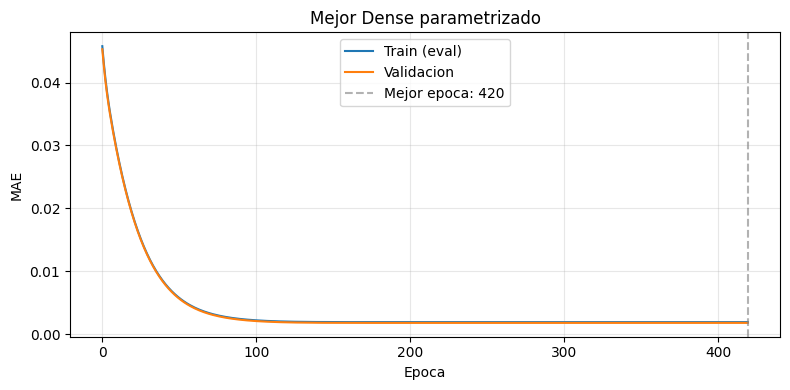

Configuracion Dense parametrizada elegida:
{'epochs': 420, 'batch_size': 512, 'lr': 0.0001, 'factor': 0.85, 'rlr_patience': 35, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 90, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 1.0, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 1.5, 'gap_excess_weight': 6.0, 'units': (64, 32), 'dropout': 0.4, 'l2': 0.0003}


In [43]:
base_cfg_dense_param = {
    'epochs': 420, #num max de epocas de entrenaminto
    'batch_size': 512, #num de muestras procesadas
    'lr': 3e-4, #LR inicial, el tamaño de los pasos del optimizador
    'factor': 0.85, #factor por el cual se reduce el LR cuando se estanca
    'rlr_patience': 35, #Si durante esas epocs no mejora, bajar el LR por el factor
    'min_delta': 1e-8, #mejora minima para considerar merjora real
    'min_lr': 5e-7, #LR minimo permitido
    'es_patience': 90, #Paciencia para EarlyStopping
    'restore_best_weights': True, #recupera los pesos de la mejor epoc
    'seed': 42, #semilla aleatoria para reproducibilidad
    'clipnorm': 1.0, #limita la norma de los gradientes para evitar saltos grandes
    'verbose': 0, #entrenamiento silencioso
    'track_train_eval': True, #evalua train durante el entrenamiento para controlar sobreajuste
    'train_eval_samples': 3000, #muestras de train usadas para esa evaluacion
    'gap_metric': 'train_eval_loss', #metrica de train usada para comparar contra validacion
    'es_monitor': 'balanced_score', #metrica que vigila EarlyStopping
    'rlr_monitor': 'balanced_score', #metrica que vigila ReduceLROnPlateau
    'gap_target': 1e-4, #gap train-validacion aceptable antes de penalizar fuerte
    'gap_weight': 1.5, #peso de la penalizacion por gap en el score balanceado
    'gap_excess_weight': 6.0, #penalizacion extra cuando el gap supera el objetivo
}

candidatos_dense_param = [
    {'nombre': 'Dense_param_128_64_32', 'units': (128, 64, 32), 'dropout': 0.30, 'l2': 1e-4, 'lr': 3e-4},
    {'nombre': 'Dense_param_96_48', 'units': (96, 48), 'dropout': 0.35, 'l2': 2e-4, 'lr': 2e-4},
    {'nombre': 'Dense_param_64_32', 'units': (64, 32), 'dropout': 0.40, 'l2': 3e-4, 'lr': 1e-4},
]

df_dense_param, hist_dense_param, modelo_dense_param, resultado_dense_param = entrenar_candidatos_parametricos(
    'construir_dense_v2_param',
    candidatos_dense_param,
    base_cfg_dense_param,
    X_train, y_train,
    X_val, y_val,
    X_train_plano, X_val_plano, X_test_plano, y_test,
)

display(df_dense_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_dense_param, 'Mejor Dense parametrizado')
print('Configuracion Dense parametrizada elegida:')
print(resultado_dense_param['cfg'])


## 1.3.2 Seleccion del mejor Dense


In [44]:
candidatos_dense_final = [(r['modelo'], r) for r in resultados_dense_opciones]
candidatos_dense_final.append((resultado_dense_param['modelo'], resultado_dense_param))
resultado_dense, df_seleccion_dense = seleccionar_mejor_familia(candidatos_dense_final, 'Dense')


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Dense_v6,Dense,0.002175,0.001775,0.002331,20791
1,Dense_v5,Dense,0.002140,0.001778,0.002346,65047
2,Dense_v4,Dense,0.002175,0.001778,0.002322,39319
3,Dense_v3,Dense,0.002171,0.001780,0.002319,292247
4,Dense_v2,Dense,0.002175,0.001781,0.002320,40663
5,Dense,Dense,0.002173,0.001784,0.002317,94999
6,Dense_param_64_32,Dense,0.002172,0.001786,0.002320,17623


Resultado activo para Dense: Dense_v6


## 1.4 LSTM



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 41: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 47: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 47: early stopping
Restoring model weights from the end of the best epoch: 29.
{'modelo': 'LSTM_modelos.py', 'mae_train': 0.0021495254745771686, 'mae_val': 0.0017643658703531072, 'mae_test': 0.0023438014383444397, 'n_params': 24023}


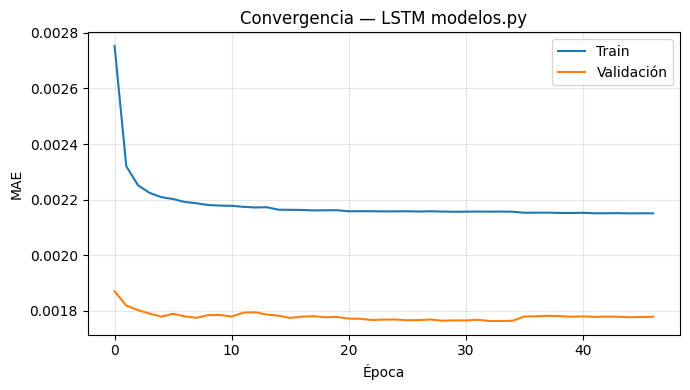

In [63]:
keras.backend.clear_session()
keras.utils.set_random_seed(142)
modelo_lstm_default = construir_recurrente(X_train.shape[1:], y_train.shape[1])
hist_lstm_default = modelo_lstm_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_lstm_default, 'LSTM')
resultado_lstm_default = evaluar_modelo(
    modelo_lstm_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='LSTM_modelos.py',
)
print(resultado_lstm_default)


## 1.4.1 Busqueda del mejor LSTM parametrizado


Entrenando LSTM_param_16_reg (1/3)...
{'mae_train': 0.0021714294403172105, 'mae_val': 0.001785288581653795, 'mae_test': 0.0023196667014469354, 'best_train_val_gap': 0.00011817016638815403, 'best_epoch': 520}
Entrenando LSTM_param_24_reg (2/3)...
{'mae_train': 0.002171105941830277, 'mae_val': 0.0017835750030272119, 'mae_test': 0.0023194033343231124, 'best_train_val_gap': 0.00011961557902395725, 'best_epoch': 520}
Entrenando LSTM_param_32_reg_fuerte (3/3)...
{'mae_train': 0.002171169811933014, 'mae_val': 0.001783510028106437, 'mae_test': 0.002319388971717153, 'best_train_val_gap': 0.0001197117380797863, 'best_epoch': 520}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,LSTM_param_16_reg,0.002171,0.001785,0.002320,0.002369,0.000118,520,2951
1,LSTM_param_24_reg,0.002171,0.001784,0.002319,0.003038,0.000120,520,5183
2,LSTM_param_32_reg_fuerte,0.002171,0.001784,0.002319,0.004442,0.000120,520,7927


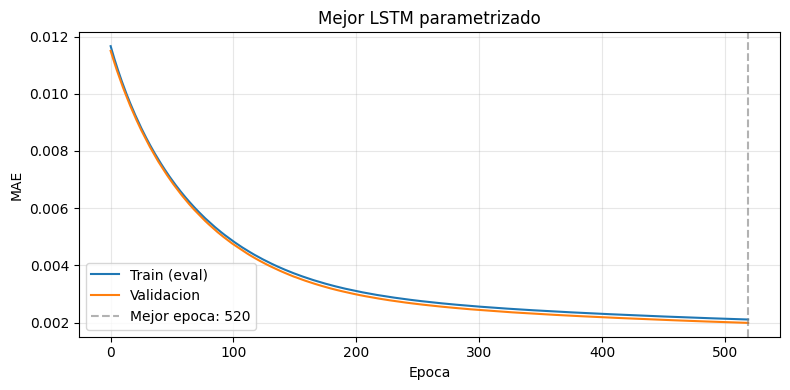

Configuracion LSTM parametrizada elegida:
{'epochs': 520, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 45, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 120, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'recurrent_dropout': 0.0, 'units': 16, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,LSTM_modelos.py,LSTM,0.002150,0.001764,0.002344,24023
1,LSTM_param_16_reg,LSTM,0.002171,0.001785,0.002320,2951


Resultado activo para LSTM: LSTM_modelos.py


In [46]:
base_cfg_lstm = {
    'epochs': 520, #num max de epocas de entrenaminto
    'batch_size': 512, #num de muestras procesadas
    'lr': 5e-5, #LR inicial, el tamaño de los pasos del optimizador
    'factor': 0.88, #factor por el cual se reduce el LR cuando se estanca
    'rlr_patience': 45, #Si durante esas epocs no mejora, bajar el LR por el factor
    'min_delta': 1e-8, #mejora minima para considerar merjora real
    'min_lr': 5e-7, #LR minimo permitido
    'es_patience': 120, #Paciencia para EarlyStopping
    'restore_best_weights': True, #recupera los pesos de la mejor epoc
    'seed': 42, #semilla aleatoria para reproducibilidad
    'clipnorm': 0.5, #limita la norma de los gradientes para evitar saltos grandes
    'verbose': 0, #entrenamiento silencioso
    'track_train_eval': True, #evalua train durante el entrenamiento para controlar sobreajuste
    'train_eval_samples': 3000, #muestras de train usadas para esa evaluacion
    'gap_metric': 'train_eval_loss', #metrica de train usada para comparar contra validacion
    'es_monitor': 'balanced_score', #metrica que vigila EarlyStopping
    'rlr_monitor': 'balanced_score', #metrica que vigila ReduceLROnPlateau
    'gap_target': 1e-4, #gap train-validacion aceptable antes de penalizar fuerte
    'gap_weight': 2.0, #peso de la penalizacion por gap en el score balanceado
    'gap_excess_weight': 8.0, #penalizacion extra cuando el gap supera el objetivo
    'recurrent_dropout': 0.0,
}

candidatos_lstm = [
    {'nombre': 'LSTM_param_16_reg', 'units': 16, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'LSTM_param_24_reg', 'units': 24, 'dropout': 0.35, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'LSTM_param_32_reg_fuerte', 'units': 32, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_lstm_param, hist_lstm_param, modelo_lstm_param, resultado_lstm_param = entrenar_candidatos_parametricos(
    'construir_lstm_param',
    candidatos_lstm,
    base_cfg_lstm,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test, y_test,
)

display(df_lstm_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_lstm_param, 'Mejor LSTM parametrizado')
print('Configuracion LSTM parametrizada elegida:')
print(resultado_lstm_param['cfg'])

resultado_lstm, df_seleccion_lstm = seleccionar_mejor_familia(
    [('LSTM_modelos.py', resultado_lstm_default), (resultado_lstm_param['modelo'], resultado_lstm_param)],
    'LSTM',
)


## 1.5 Modelo Conv1D


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 2.
{'modelo': 'Conv1D_modelos.py', 'mae_train': 0.0021750424466615375, 'mae_val': 0.0017795445756540141, 'mae_test': 0.0023275747204614533, 'n_params': 11415}


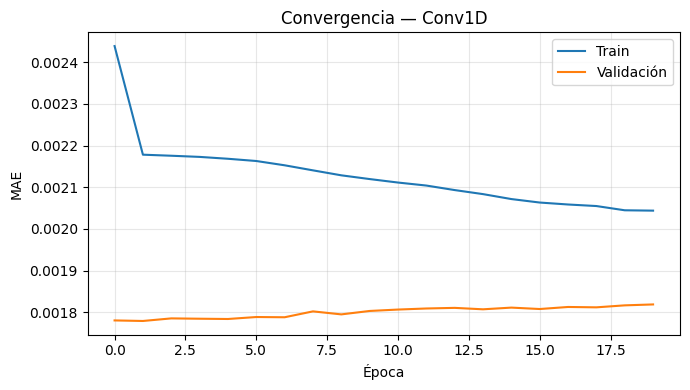

In [61]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)
modelo_conv_default = construir_conv1d(X_train.shape[1:], y_train.shape[1])
hist_conv_default = modelo_conv_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_conv_default, 'Conv1D')
resultado_conv_default = evaluar_modelo(
    modelo_conv_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='Conv1D_modelos.py',
)
print(resultado_conv_default)


## 1.5.1 Busqueda del mejor Conv1D parametrizado


Entrenando Conv1D_param_16 (1/3)...
{'mae_train': 0.0021714347891584524, 'mae_val': 0.001785383962810275, 'mae_test': 0.0023196665877807227, 'best_train_val_gap': 0.000118100899271667, 'best_epoch': 445}
Entrenando Conv1D_param_24 (2/3)...
{'mae_train': 0.00217117207979366, 'mae_val': 0.0017836115034771392, 'mae_test': 0.0023193723458980907, 'best_train_val_gap': 0.00011962710414081812, 'best_epoch': 460}
Entrenando Conv1D_param_32_k5 (3/3)...
{'mae_train': 0.0021711720906648067, 'mae_val': 0.0017835731293697316, 'mae_test': 0.002319385119022137, 'best_train_val_gap': 0.00011966517195105553, 'best_epoch': 460}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Conv1D_param_16,0.002171,0.001785,0.002320,0.002166,0.000118,445,1719
1,Conv1D_param_24,0.002171,0.001784,0.002319,0.002203,0.000120,460,2855
2,Conv1D_param_32_k5,0.002171,0.001784,0.002319,0.002209,0.000120,460,6679


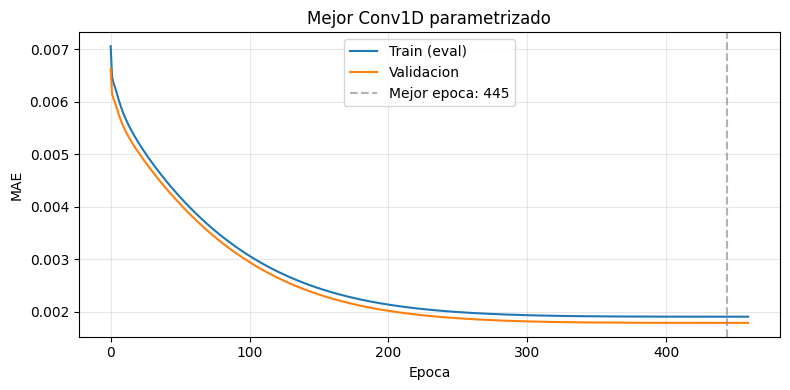

Configuracion Conv1D parametrizada elegida:
{'epochs': 460, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 40, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 110, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'filtros': 16, 'kernel': 3, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Conv1D_param_16,Conv1D,0.002171,0.001785,0.002320,1719
1,Conv1D_modelos.py,Conv1D,0.002117,0.001796,0.002341,11415


Resultado activo para Conv1D: Conv1D_param_16


In [48]:
base_cfg_conv = {
    'epochs': 460, #num max de epocas de entrenaminto
    'batch_size': 512, #num de muestras procesadas
    'lr': 5e-5, #LR inicial, el tamaño de los pasos del optimizador
    'factor': 0.88, #factor por el cual se reduce el LR cuando se estanca
    'rlr_patience': 40, #Si durante 40 epocs no mejora, bajar el LR por el factor
    'min_delta': 1e-8, #mejora minima para considerar merjora real
    'min_lr': 5e-7, #LR minimo permitido
    'es_patience': 110, #Paciencia para EarlyStopping
    'restore_best_weights': True, #recupera los pesos de la mejor epoc
    'seed': 42, #semilla aleatoria para reproducibilidad
    'clipnorm': 0.5, #limita la norma de los gradientes para evitar saltos grandes
    'verbose': 0, #entrenamiento silencioso
    'track_train_eval': True, #evalua train durante el entrenamiento para controlar sobreajuste
    'train_eval_samples': 3000, #muestras de train usadas para esa evaluacion
    'gap_metric': 'train_eval_loss', #metrica de train usada para comparar contra validacion
    'es_monitor': 'balanced_score', #metrica que vigila EarlyStopping
    'rlr_monitor': 'balanced_score', #metrica que vigila ReduceLROnPlateau
    'gap_target': 1e-4, #gap train-validacion aceptable antes de penalizar fuerte
    'gap_weight': 2.0, #peso de la penalizacion por gap en el score balanceado
    'gap_excess_weight': 8.0, #penalizacion extra cuando el gap supera el objetivo
}

candidatos_conv = [
    {'nombre': 'Conv1D_param_16', 'filtros': 16, 'kernel': 3, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Conv1D_param_24', 'filtros': 24, 'kernel': 3, 'dropout': 0.40, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Conv1D_param_32_k5', 'filtros': 32, 'kernel': 5, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_conv_param, hist_conv_param, modelo_conv_param, resultado_conv_param = entrenar_candidatos_parametricos(
    'construir_conv1d_param',
    candidatos_conv,
    base_cfg_conv,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test, y_test,
)

display(df_conv_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_conv_param, 'Mejor Conv1D parametrizado')
print('Configuracion Conv1D parametrizada elegida:')
print(resultado_conv_param['cfg'])

resultado_conv, df_seleccion_conv = seleccionar_mejor_familia(
    [('Conv1D_modelos.py', resultado_conv_default), (resultado_conv_param['modelo'], resultado_conv_param)],
    'Conv1D',
)


## 1.6 Modelo Mixto (Conv1D + LSTM)



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 5.
{'modelo': 'Mixto_modelos.py', 'mae_train': 0.0021171595554034775, 'mae_val': 0.0017797438957438255, 'mae_test': 0.0023717481936574897, 'n_params': 38999}


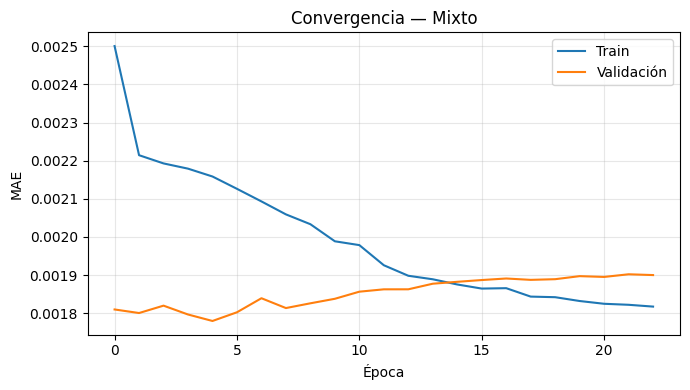

In [64]:
keras.backend.clear_session()
keras.utils.set_random_seed(342)
modelo_mixto_default = construir_mixto(X_train.shape[1:], y_train.shape[1])
hist_mixto_default = modelo_mixto_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_mixto_default, 'Mixto')
resultado_mixto_default = evaluar_modelo(
    modelo_mixto_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='Mixto_modelos.py',
)
print(resultado_mixto_default)


## 1.6.1 Busqueda del mejor Mixto parametrizado


Entrenando Mixto_param_16_12 (1/3)...
{'mae_train': 0.0021714301384946045, 'mae_val': 0.0017852904736093001, 'mae_test': 0.002319697245853417, 'best_train_val_gap': 0.00011818937491625547, 'best_epoch': 540}
Entrenando Mixto_param_24_16 (2/3)...
{'mae_train': 0.0021711687114535543, 'mae_val': 0.0017834688662273774, 'mae_test': 0.002319359178397712, 'best_train_val_gap': 0.00011975038796663284, 'best_epoch': 540}
Entrenando Mixto_param_24_12_k5 (3/3)...
{'mae_train': 0.00217117259824138, 'mae_val': 0.001783510974776919, 'mae_test': 0.002319331911009097, 'best_train_val_gap': 0.00011974247172474861, 'best_epoch': 540}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Mixto_param_16_12,0.002171,0.001785,0.002320,0.002298,0.000118,540,2811
1,Mixto_param_24_16,0.002171,0.001783,0.002319,0.002730,0.000120,540,4695
2,Mixto_param_24_12_k5,0.002171,0.001784,0.002319,0.003003,0.000120,540,4859


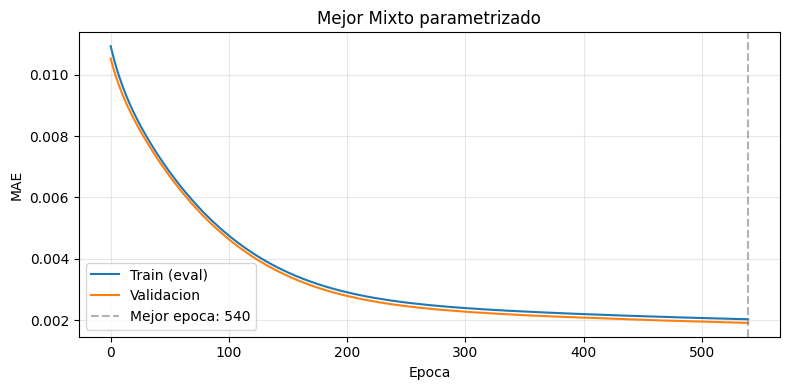

Configuracion Mixto parametrizada elegida:
{'epochs': 540, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 45, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 120, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'filtros': 16, 'lstm_units': 12, 'kernel': 3, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Mixto_modelos.py,Mixto,0.002117,0.001780,0.002372,38999
1,Mixto_param_16_12,Mixto,0.002171,0.001785,0.002320,2811


Resultado activo para Mixto: Mixto_modelos.py


In [50]:
base_cfg_mixto = {
    'epochs': 540, #num max de epocas de entrenaminto
    'batch_size': 512, #num de muestras procesadas
    'lr': 5e-5, #LR inicial, el tamaño de los pasos del optimizador
    'factor': 0.88, #factor por el cual se reduce el LR cuando se estanca
    'rlr_patience': 45, #Si durante esas epocs no mejora, bajar el LR por el factor
    'min_delta': 1e-8, #mejora minima para considerar merjora real
    'min_lr': 5e-7, #LR minimo permitido
    'es_patience': 120, #Paciencia para EarlyStopping
    'restore_best_weights': True, #recupera los pesos de la mejor epoc
    'seed': 42, #semilla aleatoria para reproducibilidad
    'clipnorm': 0.5, #limita la norma de los gradientes para evitar saltos grandes
    'verbose': 0, #entrenamiento silencioso
    'track_train_eval': True, #evalua train durante el entrenamiento para controlar sobreajuste
    'train_eval_samples': 3000, #muestras de train usadas para esa evaluacion
    'gap_metric': 'train_eval_loss', #metrica de train usada para comparar contra validacion
    'es_monitor': 'balanced_score', #metrica que vigila EarlyStopping
    'rlr_monitor': 'balanced_score', #metrica que vigila ReduceLROnPlateau
    'gap_target': 1e-4, #gap train-validacion aceptable antes de penalizar fuerte
    'gap_weight': 2.0, #peso de la penalizacion por gap en el score balanceado
    'gap_excess_weight': 8.0, #penalizacion extra cuando el gap supera el objetivo
}

candidatos_mixto = [
    {'nombre': 'Mixto_param_16_12', 'filtros': 16, 'lstm_units': 12, 'kernel': 3, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Mixto_param_24_16', 'filtros': 24, 'lstm_units': 16, 'kernel': 3, 'dropout': 0.40, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Mixto_param_24_12_k5', 'filtros': 24, 'lstm_units': 12, 'kernel': 5, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_mixto_param, hist_mixto_param, modelo_mixto_param, resultado_mixto_param = entrenar_candidatos_parametricos(
    'construir_mixto_param',
    candidatos_mixto,
    base_cfg_mixto,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test, y_test,
)

display(df_mixto_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_mixto_param, 'Mejor Mixto parametrizado')
print('Configuracion Mixto parametrizada elegida:')
print(resultado_mixto_param['cfg'])

resultado_mixto, df_seleccion_mixto = seleccionar_mejor_familia(
    [('Mixto_modelos.py', resultado_mixto_default), (resultado_mixto_param['modelo'], resultado_mixto_param)],
    'Mixto',
)


## 1.7 Resumen de competicion y guardado


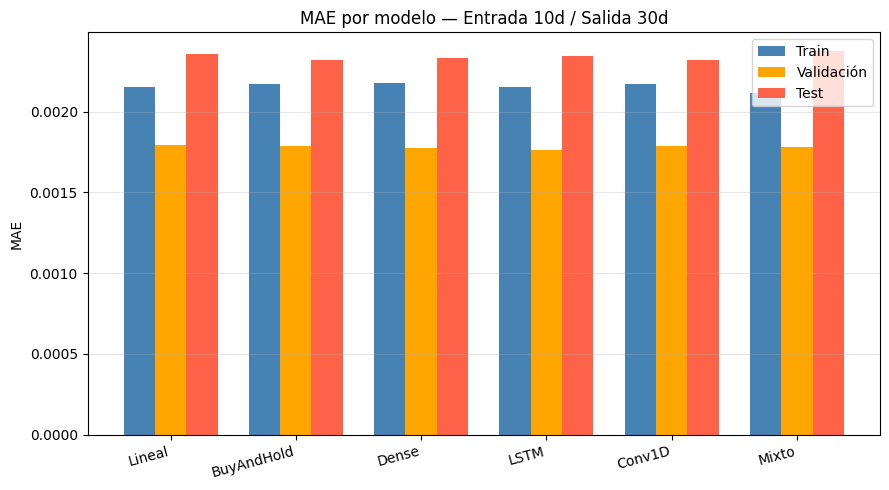

Resultados [competicion] guardados en: ../resultados/metricas/ent10_sal30.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.002152,0.001795,0.002355,0
BuyAndHold,0.002173,0.001784,0.002319,0
Dense,0.002175,0.001775,0.002331,20791
LSTM,0.002150,0.001764,0.002344,24023
Conv1D,0.002171,0.001785,0.002320,1719
Mixto,0.002117,0.001780,0.002372,38999


In [51]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))

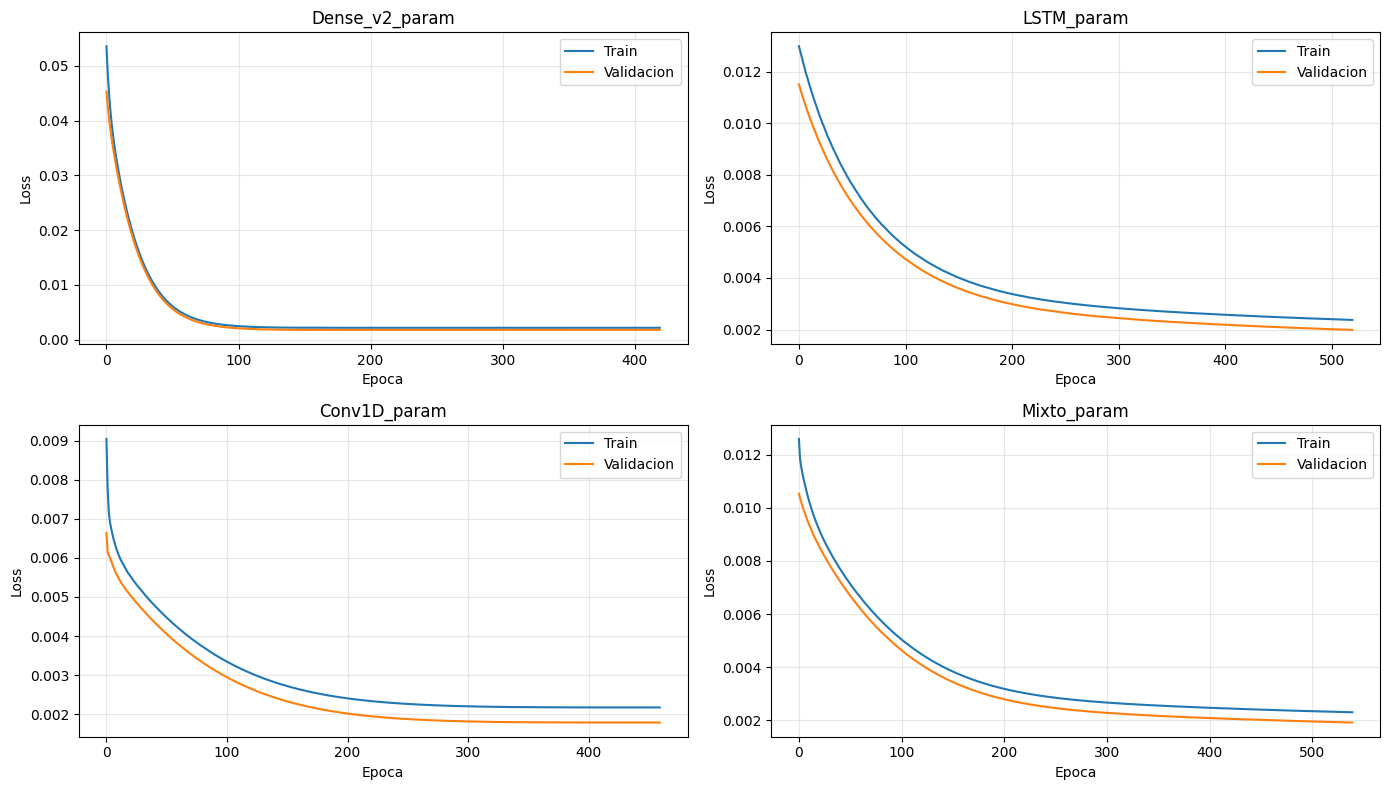

In [60]:
# Curvas de entrenamiento de los mejores modelos parametrizados
historias_mejores = [
    ('Dense_v2_param', hist_dense_param),
    ('LSTM_param', hist_lstm_param),
    ('Conv1D_param', hist_conv_param),
    ('Mixto_param', hist_mixto_param),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (nombre, historia) in zip(axes.ravel(), historias_mejores):
    ax.plot(historia.history['loss'], label='Train')
    ax.plot(historia.history['val_loss'], label='Validacion')
    ax.set_title(nombre)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Resultados de Lineal, BuyAndHold y mejores modelos neuronales
df_mejores = pd.DataFrame([
    resultado_lineal,
    resultado_bah,
    resultado_dense,
    resultado_lstm,
    resultado_conv,
    resultado_mixto,
]).set_index('modelo')[['mae_train', 'mae_val', 'mae_test']]


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [53]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


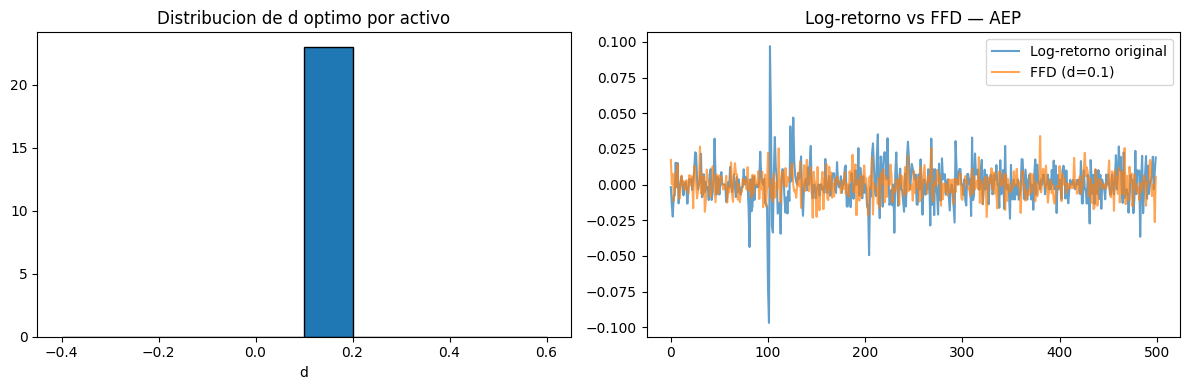

In [54]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [55]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de señal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


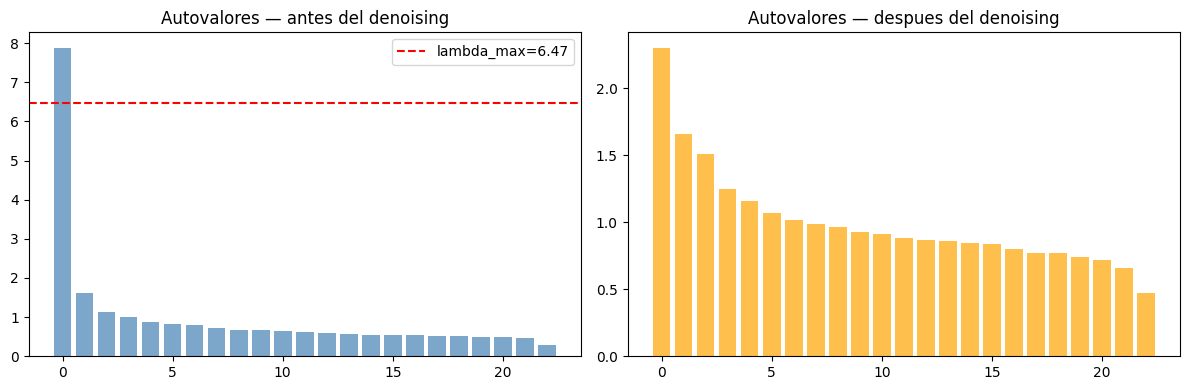

In [56]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de señal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [57]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (13381, 10, 23)  Val: (705, 10, 23)  Test: (1566, 10, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Conv1D
Epoch 1/100


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0999 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0941 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0933 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0923 - val_loss: 0.0876 - learning_rate: 0.0010
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0911 - val_loss: 0.0879 - learning_rate: 0.0010
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0898 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 7/100
192/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0893
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0886 - val_loss: 0.0886 - learning_rate: 0.0010
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0874 - val_loss: 0.0887 - learning_rate:

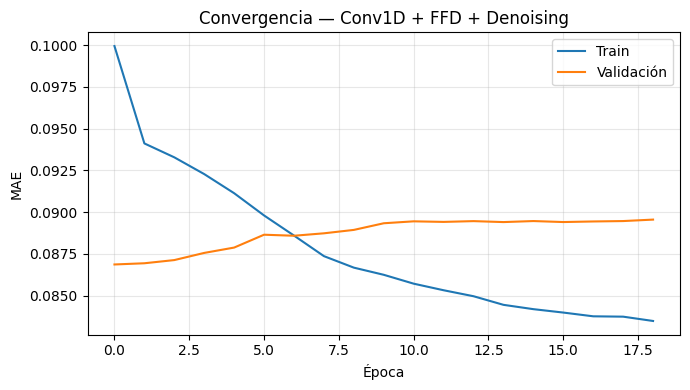

In [58]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Conv1D,0.002171,0.001785,0.002320,1719
Conv1D_prep,0.094274,0.086872,0.105601,11415


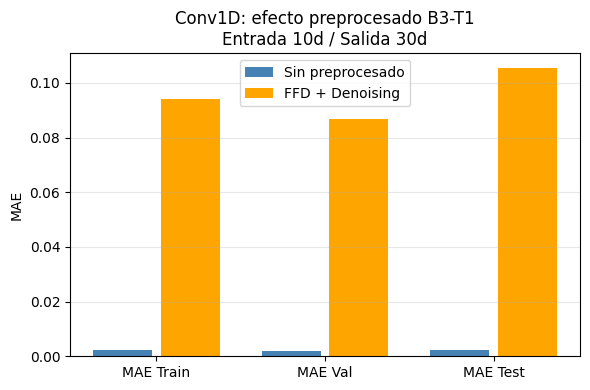

Variacion MAE test con preprocesado: -4452.4%
Resultados [investigacion] guardados en: ../resultados/metricas/ent10_sal30.json


In [59]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
